# Binary recovery with grid search and HMC

This notebook mirrors the docs tutorial and adds a Fisher-reparameterized HMC path.

In [1]:
import warnings
import jax
import jax.numpy as jnp
import numpy as onp
import pandas as pd
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree

warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

from drpangloss.models import OIData, BinaryModelCartesian, loglike
from drpangloss.grid_fit import likelihood_grid
from drpangloss.inference import fisher_matrix, fisher_projection
from drpangloss.plotting import (
    posterior_predictive_summary,
    plot_data_model_correlation,
    plot_likelihood_grid,
    plot_chainconsumer_diagnostics,
    diagnostics_table_from_samples,
    truth_cartesian_and_polar,
)

## 1) Build a compact synthetic dataset
Create synthetic $V^2$ and phase observables from a known binary model so recovery can be validated against truth.

In [2]:
rng = onp.random.default_rng(42)
n_bl = 24
u = jnp.array(rng.uniform(-28.0, 28.0, size=n_bl))
v = jnp.array(rng.uniform(-28.0, 28.0, size=n_bl))
wavel = jnp.array([4.8e-6])

truth = {"dra": 120.0, "ddec": -80.0, "flux": 4e-3}
model_true = BinaryModelCartesian(**truth)
cvis_true = model_true.model(u, v, wavel)

vis_true = jnp.abs(cvis_true) ** 2
phi_true = jnp.rad2deg(jnp.angle(cvis_true))

# Synthetic noise as percentage of data scale (phase in degrees), boosted SNR by 5x.
vis_scale = jnp.maximum(jnp.median(vis_true), 1e-6)
phi_scale = jnp.maximum(jnp.median(jnp.abs(phi_true)), 5.0)
d_vis = 0.001 * vis_scale * jnp.ones_like(vis_true)
d_phi = 0.004 * phi_scale * jnp.ones_like(phi_true)

vis_obs = vis_true + d_vis * jnp.array(rng.normal(size=vis_true.shape))
phi_obs = phi_true + d_phi * jnp.array(rng.normal(size=phi_true.shape))

data = OIData({
    "u": u,
    "v": v,
    "wavel": wavel,
    "vis": vis_obs,
    "d_vis": d_vis,
    "phi": phi_obs,
    "d_phi": d_phi,
    "i_cps1": None,
    "i_cps2": None,
    "i_cps3": None,
    "v2_flag": True,
    "cp_flag": False,
})

## 2) Coarse likelihood-grid recovery
Run a broad grid over $(\Delta\mathrm{RA}, \Delta\mathrm{Dec}, \mathrm{flux})$ to locate a robust starting point for MCMC.

In [3]:
samples = {
    "dra": jnp.linspace(-250.0, 250.0, 81),
    "ddec": jnp.linspace(-250.0, 250.0, 81),
    "flux": 10 ** jnp.linspace(-4.5, -1.5, 60),
}

ll_cube = likelihood_grid(data, BinaryModelCartesian, samples)
max_idx = jnp.unravel_index(jnp.argmax(ll_cube), ll_cube.shape)
grid_est = {
    "dra": float(samples["dra"][max_idx[0]]),
    "ddec": float(samples["ddec"][max_idx[1]]),
    "flux": float(samples["flux"][max_idx[2]]),
}
grid_est

{'dra': 118.75, 'ddec': -81.25, 'flux': 0.0038436660543084145}

## 2b) Visualize the grid structure
This map is a fast sanity check before MCMC. The bright region should sit near the truth marker, and the grid maximum provides a robust initialization point for subsequent samplers.

Because we marginalize over flux here (taking the max over the flux axis), this panel emphasizes positional structure in $(\Delta\mathrm{RA}, \Delta\mathrm{Dec})$ while keeping the notebook compact.

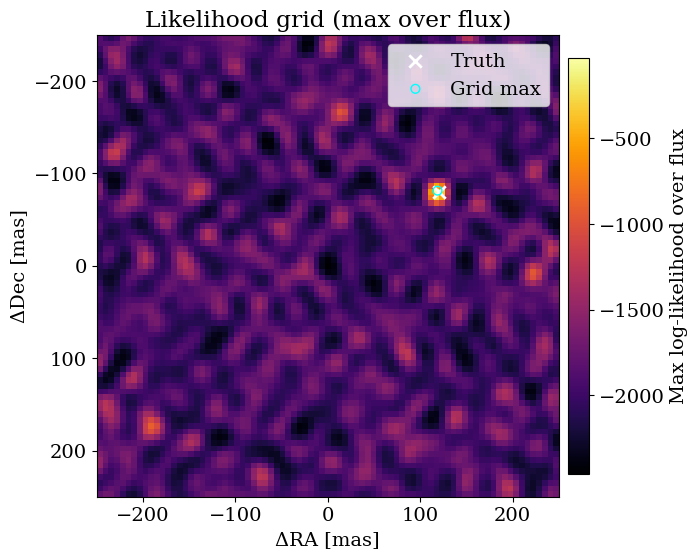

In [4]:
ll_2d = ll_cube.max(axis=2)
plot_likelihood_grid(
    ll_2d,
    samples,
    truths=truth,
    best_point=grid_est,
    colorbar_label="Max log-likelihood over flux",
)
plt.title("Likelihood grid (max over flux)")
plt.show()

## 3) Posterior refinement with vanilla HMC
Sample directly in physical parameters with NUTS, initialized near the grid maximum.

In [5]:
params = ["dra", "ddec", "flux"]

# Define a simple physical-parameter HMC model with bounded priors.
def model_hmc(oidata):
    dra = numpyro.sample("dra", dist.Uniform(-300.0, 300.0))
    ddec = numpyro.sample("ddec", dist.Uniform(-300.0, 300.0))
    log10_flux = numpyro.sample("log10_flux", dist.Uniform(-6.0, -1.0))
    flux = 10.0 ** log10_flux
    ll = loglike([dra, ddec, flux], params, oidata, BinaryModelCartesian)
    numpyro.factor("loglike", ll)

# Initialize near the grid maximum for robust convergence in this toy setup.
init_values = {
    "dra": float(grid_est["dra"]),
    "ddec": float(grid_est["ddec"]),
    "log10_flux": float(jnp.log10(max(grid_est["flux"], 1e-12))),
}
kernel = NUTS(model_hmc, init_strategy=init_to_value(values=init_values))
mcmc = MCMC(kernel, num_warmup=800, num_samples=2000, num_chains=1, progress_bar=False)
mcmc.run(jax.random.PRNGKey(2026), oidata=data)
posterior = mcmc.get_samples()

summary = {
    "dra_median": float(jnp.median(posterior["dra"])),
    "ddec_median": float(jnp.median(posterior["ddec"])),
    "flux_median": float(jnp.median(10.0 ** posterior["log10_flux"])),
}
summary

W0304 00:22:25.988509 2596293 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


{'dra_median': 119.70986938476562,
 'ddec_median': -80.13255310058594,
 'flux_median': 0.00393222039565444}

## 3b) Prepare vanilla HMC samples for shared diagnostics
We build a common diagnostics table in both Cartesian (`dra`, `ddec`, `flux`) and polar (`sep`, `pa`, `flux`) coordinates.

Section 4b then overlays HMC and Fisher-HMC in each coordinate system so geometry differences are visible without changing plotting style.

In [6]:
# Convert vanilla posterior samples into diagnostics table for later comparison plots.
hmc_results = diagnostics_table_from_samples(
    posterior,
    flux_key="log10_flux",
    log10_flux=True,
)

{
    "hmc_rows": len(hmc_results),
    "hmc_dra_median": float(hmc_results["dra"].median()),
    "hmc_ddec_median": float(hmc_results["ddec"].median()),
    "hmc_flux_median": float(hmc_results["flux"].median()),
}

{'hmc_rows': 2000,
 'hmc_dra_median': 119.70986557006836,
 'hmc_ddec_median': -80.13254928588867,
 'hmc_flux_median': 0.003932220572237748}

## 4) Fisher-reparameterized HMC
Whiten local geometry around the grid estimate using a Fisher projection, then sample in latent coordinates with prior correction.

In [7]:
x0_dict = {
    "dra": grid_est["dra"],
    "ddec": grid_est["ddec"],
    "log10_flux": float(jnp.log10(max(grid_est["flux"], 1e-12))),
}
x0, unravel = ravel_pytree(x0_dict)

# Build local Fisher geometry around x0 for whitening transform.
def objective(x):
    xdict = unravel(x)
    flux = 10.0 ** xdict["log10_flux"]
    values = jnp.array([xdict["dra"], xdict["ddec"], flux])
    return -loglike(values, params, data, BinaryModelCartesian)

F = fisher_matrix(objective, x0, ridge=1e-8)
P = fisher_projection(F)

# Sample in latent coordinates and apply explicit prior correction back to physical priors.
def model_hmc_fisher(oidata):
    u_latent = numpyro.sample("u", dist.Normal(0.0, 1.0).expand([x0.shape[0]]).to_event(1))
    log_q_u = dist.Normal(0.0, 1.0).log_prob(u_latent).sum()
    x = x0 + jnp.dot(P, u_latent)
    xdict = unravel(x)
    dra = xdict["dra"]
    ddec = xdict["ddec"]
    log10_flux = xdict["log10_flux"]
    flux = 10.0 ** log10_flux
    numpyro.deterministic("dra", dra)
    numpyro.deterministic("ddec", ddec)
    numpyro.deterministic("flux", flux)
    log_prior_x = (
        dist.Uniform(-300.0, 300.0).log_prob(dra)
        + dist.Uniform(-300.0, 300.0).log_prob(ddec)
        + dist.Uniform(-6.0, -1.0).log_prob(log10_flux)
    )
    numpyro.factor("prior_correction", log_prior_x - log_q_u)
    numpyro.factor("loglike", loglike([dra, ddec, flux], params, oidata, BinaryModelCartesian))

kernel_f = NUTS(model_hmc_fisher)
mcmc_f = MCMC(kernel_f, num_warmup=800, num_samples=2000, num_chains=1, progress_bar=False)
mcmc_f.run(jax.random.PRNGKey(2027), oidata=data)
post_f = mcmc_f.get_samples()

{
    "fisher_dra_median": float(jnp.median(post_f["dra"])),
    "fisher_ddec_median": float(jnp.median(post_f["ddec"])),
    "fisher_flux_median": float(jnp.median(post_f["flux"])),
}

{'fisher_dra_median': 119.70191955566406,
 'fisher_ddec_median': -80.1236572265625,
 'fisher_flux_median': 0.003927189856767654}

## 4b) Combined HMC vs Fisher-HMC diagnostics (Cartesian and polar)
Both samplers are plotted on shared axes in Cartesian space and then again in polar space, each with matching walk/trace panels for direct comparison.

In [8]:
# Convert Fisher-HMC posterior samples and prepare shared diagnostic tables.
fisher_results = diagnostics_table_from_samples(post_f)
truth_cart, truth_polar = truth_cartesian_and_polar(truth)

{
    "fisher_rows": len(fisher_results),
    "fisher_sep_median": float(fisher_results["sep"].median()),
    "fisher_pa_median": float(fisher_results["pa"].median()),
}

{'fisher_rows': 2000,
 'fisher_sep_median': 144.04738651467596,
 'fisher_pa_median': 326.204775360319}

Parameter dra in chain HMC Cartesian is not constrained


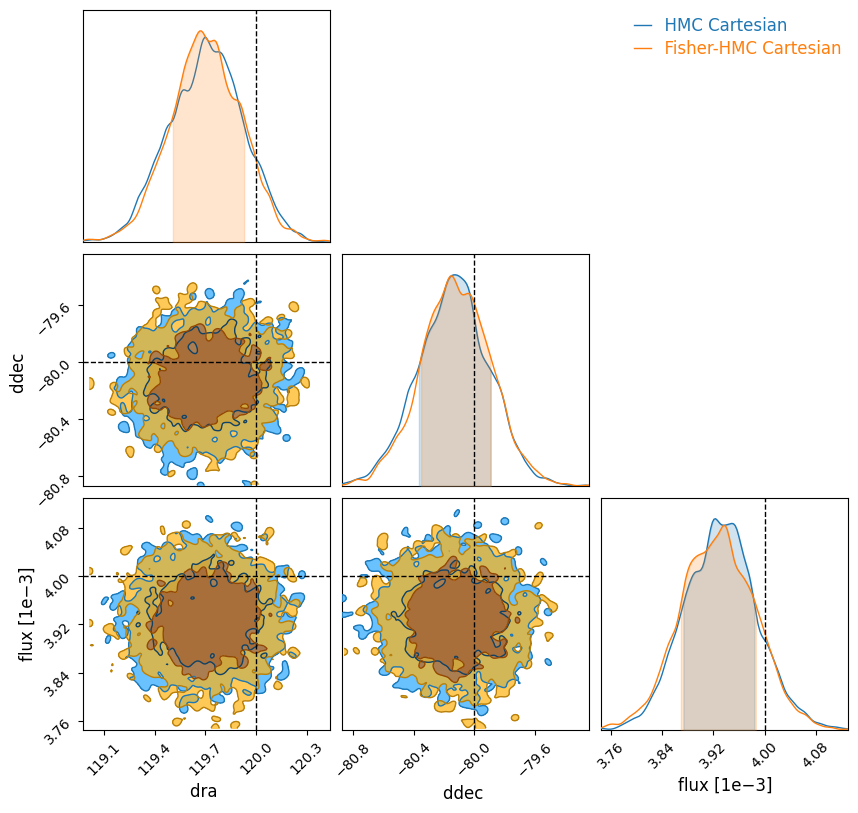

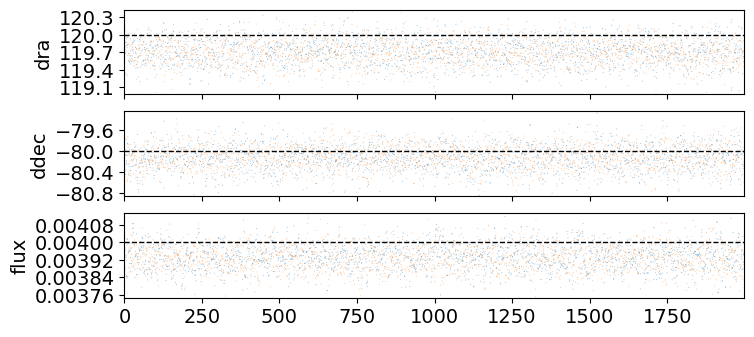

In [9]:
# Cartesian comparison plot
plot_chainconsumer_diagnostics(
    {
        "HMC Cartesian": hmc_results,
        "Fisher-HMC Cartesian": fisher_results,
    },
    columns=["dra", "ddec", "flux"],
    truth=truth_cart,
    colors=["#1f77b4", "#ff7f0e"],
)
plt.show()

Parameter sep in chain HMC Polar is not constrained


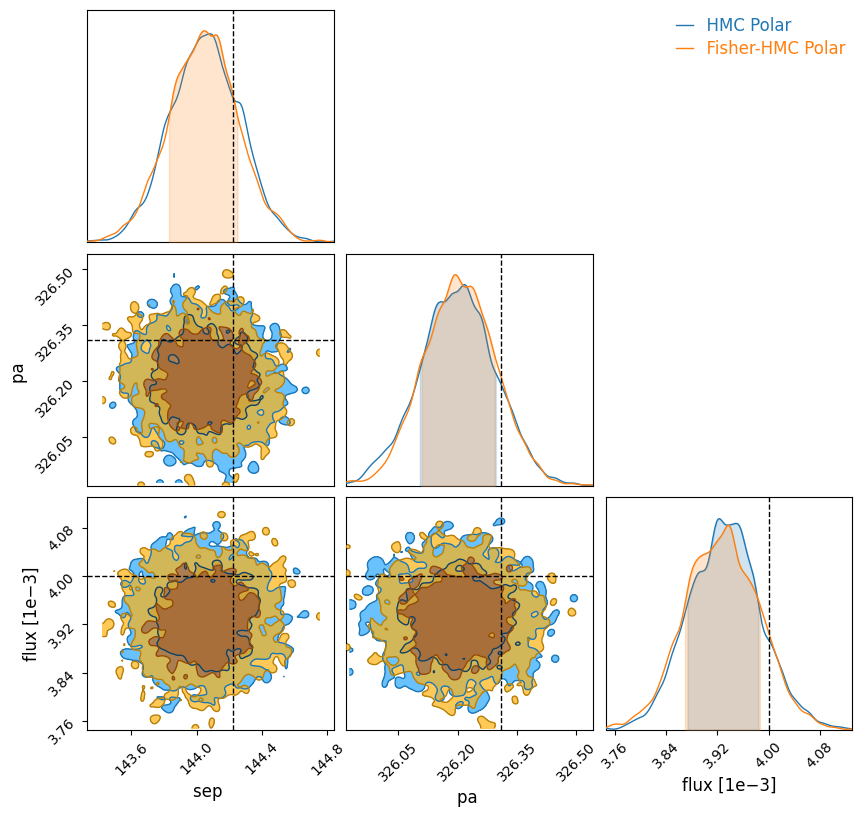

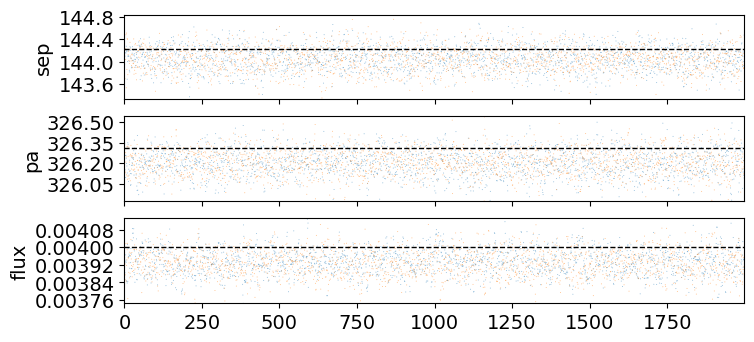

In [10]:
# Polar comparison plot
plot_chainconsumer_diagnostics(
    {
        "HMC Polar": hmc_results,
        "Fisher-HMC Polar": fisher_results,
    },
    columns=["sep", "pa", "flux"],
    truth=truth_polar,
    colors=["#1f77b4", "#ff7f0e"],
)
plt.show()

## 5) Posterior predictive correlation checks
Compare observed data against posterior predictive means for both HMC variants, with $1\!:\!1$ reference lines for visibility and phase observables.

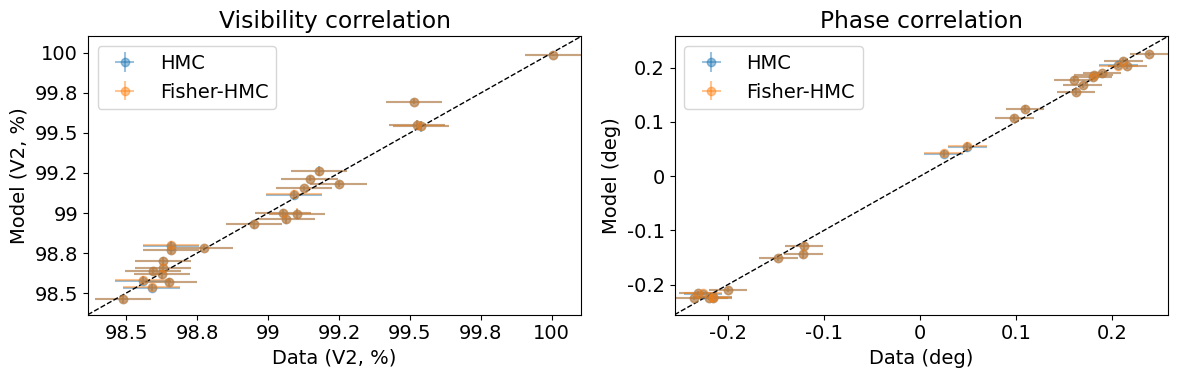

In [11]:
# Posterior predictive correlation: data vs model (HMC and Fisher-HMC)
hmc_pred = posterior_predictive_summary(
    onp.asarray(posterior["dra"]),
    onp.asarray(posterior["ddec"]),
    onp.asarray(10.0 ** posterior["log10_flux"]),
    data,
    BinaryModelCartesian,
 )

fisher_pred = posterior_predictive_summary(
    onp.asarray(post_f["dra"]),
    onp.asarray(post_f["ddec"]),
    onp.asarray(post_f["flux"]),
    data,
    BinaryModelCartesian,
 )

plot_data_model_correlation(
    data,
    {"HMC": hmc_pred, "Fisher-HMC": fisher_pred},
    colors=["C0", "C1"],
 )
plt.show()